In [ ]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ================================================================
#                     Paths and Parameters
# ================================================================
data_dir = r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset"
img_size = 96
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True   # IMPORTANT
)

val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()

val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

# ================================================================
#                Optimize Data Loading
# ================================================================
from tensorflow.keras.applications.resnet import preprocess_input

train_ds = train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds = val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds = test_ds.map(lambda x,y:(preprocess_input(x),y))

Found 59069 files belonging to 3 classes.
Using 41349 files for training.
Found 59069 files belonging to 3 classes.
Using 17720 files for validation.
Train batches: 1293
Validation batches: 277
Test batches: 277


In [2]:
# Load base ResNet152 with pretrained ImageNet weights
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3),alpha=0.25)

# First, set all layers to non-trainable (frozen)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
# Add custom classification head with regularizationg
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.7)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
#x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

C:\Users\k nithin\AppData\Local\Temp\ipykernel_30252\452920281.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3),alpha=0.25)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 48, 48, 8)           │             216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 48, 48, 8)           │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 48, 48, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 48, 48, 8)           │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 48, 48, 8)           │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 48, 48, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 48, 48, 16)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 48, 48, 16)          │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 48, 48, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 49, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 24, 24, 16)          │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 24, 24, 16)          │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 24, 24, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 24, 24, 32)          │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 24, 24, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 24, 24, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 24, 24, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 24, 24, 32)          │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 251,827 (983.70 KB)

 Trainable params: 33,283 (130.01 KB)

 Non-trainable params: 218,544 (853.69 KB)

In [3]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=3,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'Mobilenet_10_beans.keras',          # File to save
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)


# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=3e-5),  # very small lr
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train again (fine-tuning)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/10
1291/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3911 - loss: 2.0836
Epoch 1: val_accuracy improved from None to 0.66629, saving model to Mobilenet_10_beans.keras

Epoch 1: finished saving model to Mobilenet_10_beans.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 60s 45ms/step - accuracy: 0.4398 - loss: 1.7291 - val_accuracy: 0.6663 - val_loss: 0.9230
Epoch 2/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5331 - loss: 1.2401
Epoch 2: val_accuracy improved from 0.66629 to 0.71322, saving model to Mobilenet_10_beans.keras

Epoch 2: finished saving model to Mobilenet_10_beans.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.5516 - loss: 1.1986 - val_accuracy: 0.7132 - val_loss: 0.8401
Epoch 3/10
1291/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5806 - loss: 1.1036
Epoch 3: val_accuracy improved from 0.71322 to 0.72732, saving model to Mobilenet_10_beans.keras

Epoch 3: finished saving model to Mobilenet_10_beans.keras
1293/1293 ━━━━━━━━━━━━━

In [4]:
!pip install opencv-python

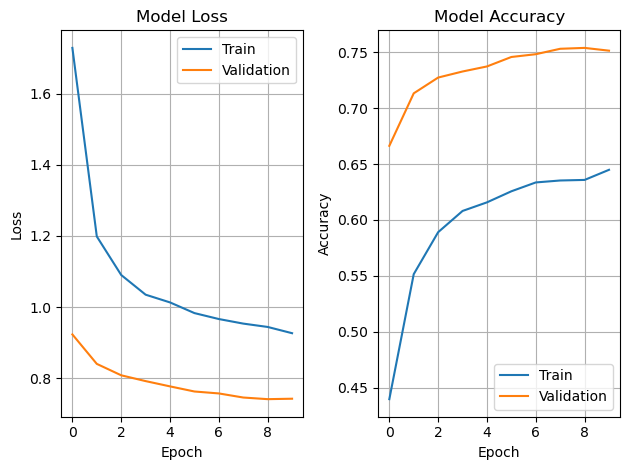

In [5]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
#save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
#plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [6]:
model.evaluate(test_ds)


ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

277/277 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.7554 - loss: 0.7388
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7555 - loss: 0.7363
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7542 - loss: 0.7408
277/277 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7568 - loss: 0.7368
Train Loss:  0.7363415956497192
Train Accuracy:  0.7555279731750488
--------------------
Validation Loss:  0.7408359050750732
Validation Accuracy:  0.7541741728782654
--------------------
Test Loss:  0.7368234395980835
Test Accuracy:  0.7567750811576843


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    #save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    #plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()


Classification Report:

              precision    recall  f1-score   support

      anthra       0.79      0.90      0.84      2056
     healthy       0.71      0.78      0.74      3708
        rust       0.81      0.64      0.71      3092

    accuracy                           0.76      8856
   macro avg       0.77      0.77      0.77      8856
weighted avg       0.76      0.76      0.75      8856



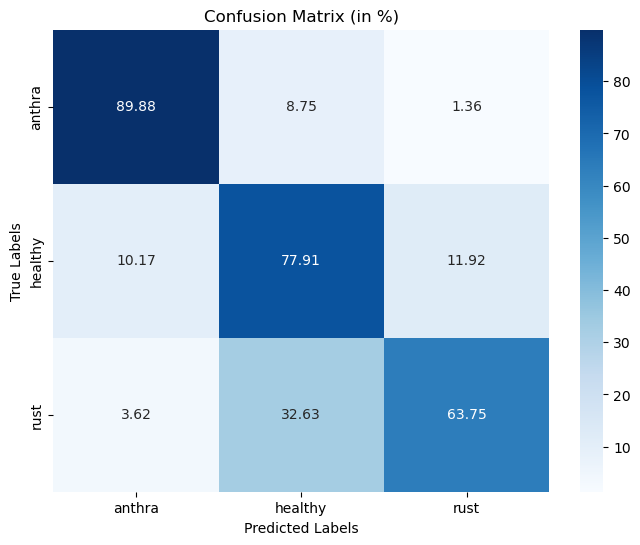

In [10]:
import numpy as np

y_true = []
y_pred = []
y_pred_probs = []   # store probabilities

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)  # probabilities
    
    y_pred_probs.extend(preds)                # save probabilities
    y_pred.extend(np.argmax(preds, axis=1))   # predicted class
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)
# IMPORTANT: correct class order (alphabetical folder order)
class_names = ['anthra','healthy','rust']

evaluate_model(y_true, y_pred, class_names)

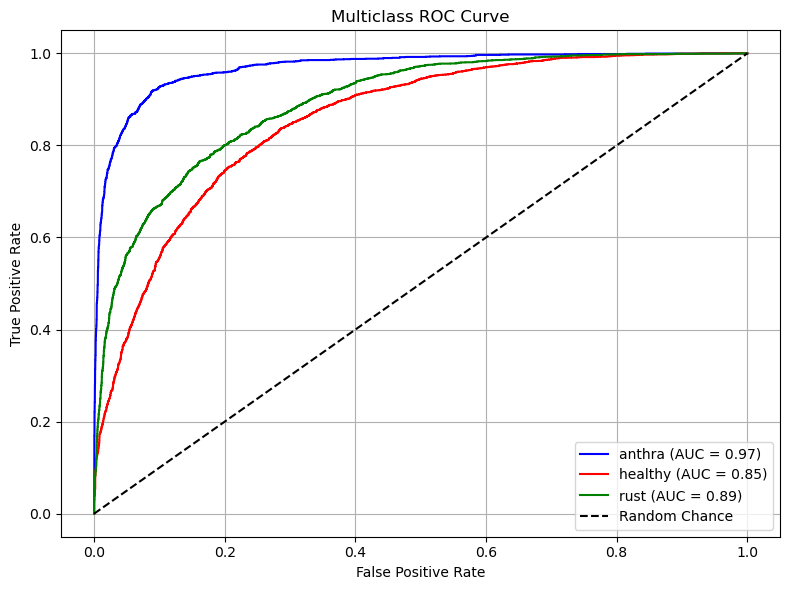

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# number of classes
n_classes = len(class_names)

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8,6))
colors = ['blue','red','green','orange','purple','cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--',label='Random Chance')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()